## 1. Database Reading


In [1]:
# ================================================================================
# 1. DATABASE READING - Read the `predicting_sales` table from `Regression.db`.
# ================================================================================

import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DB_PATH = r"D:\[18] AI-ML All\inttrvu AI\[01] Capstone Project\Data Bases\regression.db"
TABLE_NAME = "predicting_sales"

conn = sqlite3.connect(DB_PATH)
df = pd.read_sql_query(f"SELECT * FROM {TABLE_NAME}", conn)
conn.close()

print("Dataset Shape:", df.shape)
display(df.head())
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (1017209, 9)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1



Columns:
['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']


## 2. Data Inspection

In [2]:
# =====================================================================================
# 2. DATA INSPECTION - Check data types, missing values, duplicates and numerical ranges.
# =====================================================================================

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("Shape      :", df.shape)
print("Missing    :", df.isnull().sum().sum())
print("Duplicates :", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

display(df.describe())

print("\nStateHoliday values:")
print(df["StateHoliday"].dropna().unique())

DATASET INFORMATION
Shape      : (1017209, 9)
Missing    : 0
Duplicates : 0

Data Types:
Store             int64
DayOfWeek         int64
Date             object
Sales             int64
Customers         int64
Open              int64
Promo             int64
StateHoliday     object
SchoolHoliday     int64
dtype: object


,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00



StateHoliday values:
['0' 'a' 'b' 'c']


## 3. Data Cleaning & Encoding

In [3]:
# ==================================================================================================================
# 3. DATA CLEANING & ENCODING - Handle missing values, convert data types, and encode categorical variables.
# ==================================================================================================================

df["Date"] = pd.to_datetime(df["Date"], errors="coerce")

# One-hot encode StateHoliday
state_dummies = pd.get_dummies(
    df["StateHoliday"],
    prefix="StateHoliday",
    dtype=int
)

df = pd.concat([df.drop(columns=["StateHoliday"]), state_dummies], axis=1)

print("StateHoliday encoded successfully.")
display(df.head())

StateHoliday encoded successfully.


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,StateHoliday_0,StateHoliday_a,StateHoliday_b,StateHoliday_c
0,1,5,2015-07-31,5263,555,1,1,1,1,0,0,0
1,2,5,2015-07-31,6064,625,1,1,1,1,0,0,0
2,3,5,2015-07-31,8314,821,1,1,1,1,0,0,0
3,4,5,2015-07-31,13995,1498,1,1,1,1,0,0,0
4,5,5,2015-07-31,4822,559,1,1,1,1,0,0,0


## 4. Exploratory Data Analysis (EDA)

Date Range: 2013-01-01 00:00:00 to 2015-07-31 00:00:00


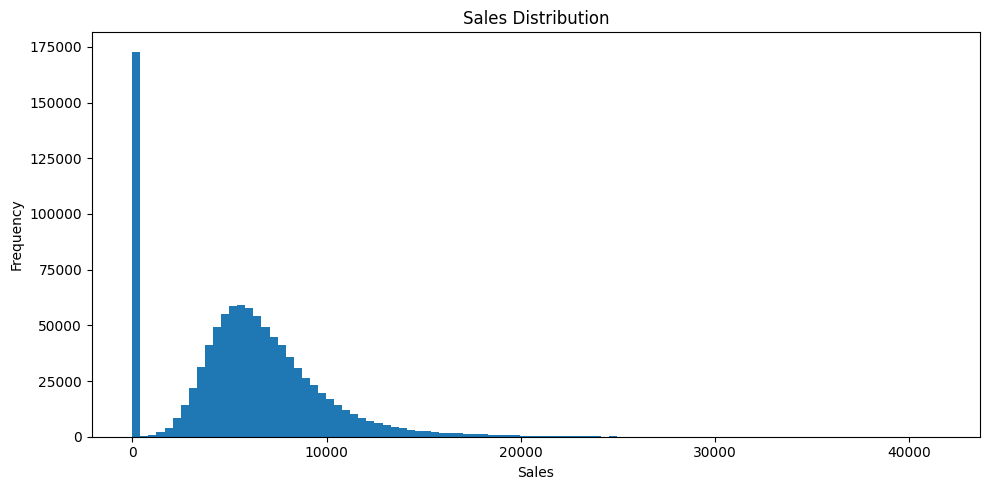

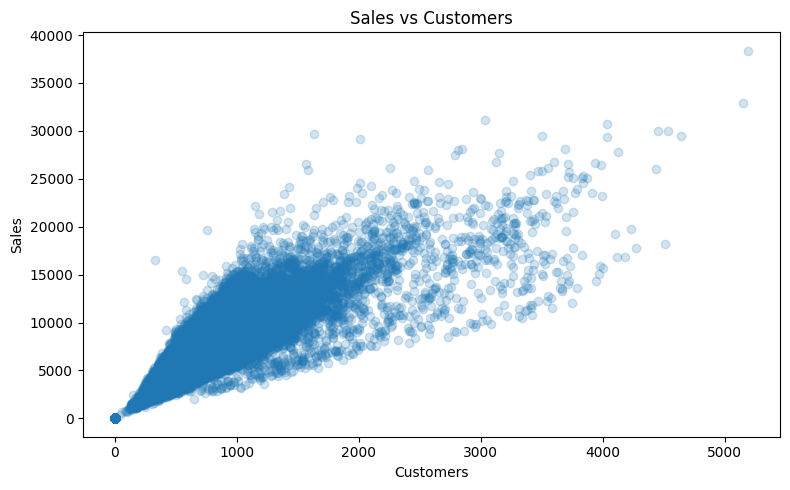

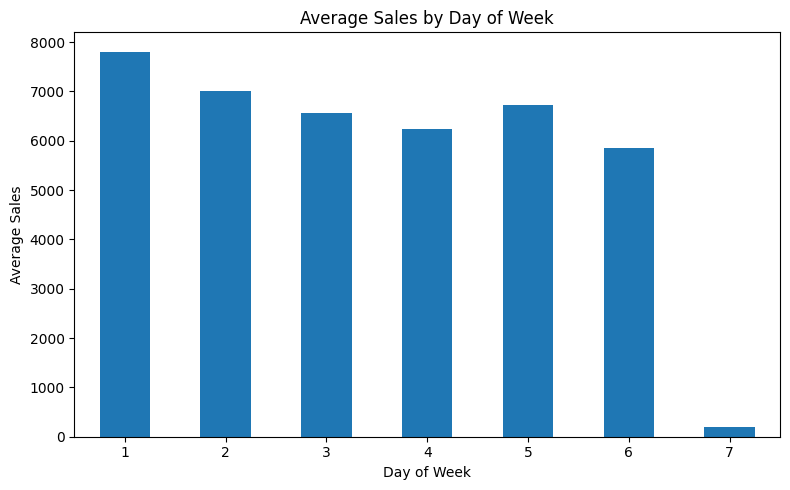

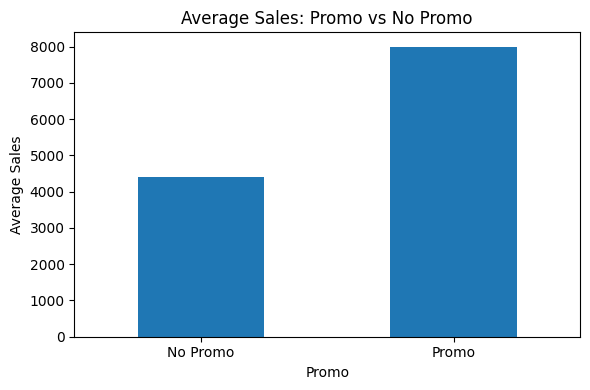

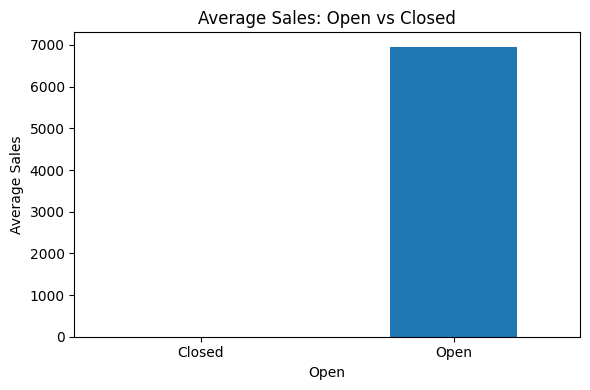

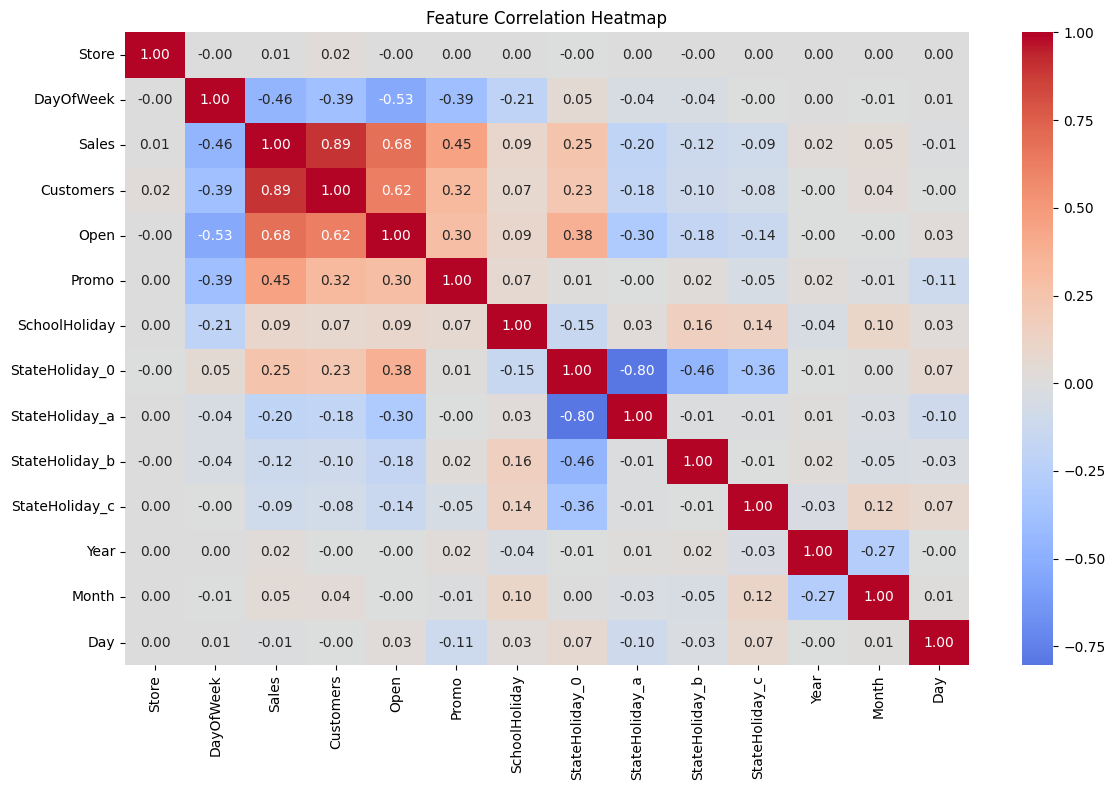

In [4]:
# ==================================================================================================================
# 4. EDA - Exploratory Data Analysis: Visualize distributions, relationships, and correlations.
# ==================================================================================================================

print("Date Range:", df["Date"].min(), "to", df["Date"].max())

# Date features used for EDA
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

# Sales distribution
plt.figure(figsize=(10, 5))
plt.hist(df["Sales"], bins=100)
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.title("Sales Distribution")
plt.tight_layout()
plt.show()

# Sales vs Customers
plt.figure(figsize=(8, 5))
sample = df.sample(min(50000, len(df)), random_state=42)
plt.scatter(sample["Customers"], sample["Sales"], alpha=0.2)
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.title("Sales vs Customers")
plt.tight_layout()
plt.show()

# Average sales by day
plt.figure(figsize=(8, 5))
df.groupby("DayOfWeek")["Sales"].mean().plot(kind="bar")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.title("Average Sales by Day of Week")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Promo effect
plt.figure(figsize=(6, 4))
df.groupby("Promo")["Sales"].mean().plot(kind="bar")
plt.xlabel("Promo")
plt.ylabel("Average Sales")
plt.title("Average Sales: Promo vs No Promo")
plt.xticks([0, 1], ["No Promo", "Promo"], rotation=0)
plt.tight_layout()
plt.show()

# Open effect
plt.figure(figsize=(6, 4))
df.groupby("Open")["Sales"].mean().plot(kind="bar")
plt.xlabel("Open")
plt.ylabel("Average Sales")
plt.title("Average Sales: Open vs Closed")
plt.xticks([0, 1], ["Closed", "Open"], rotation=0)
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(12, 8))
corr = df.select_dtypes(include="number").corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

## 5. Feature Engineering

In [5]:
# ==================================================================================================================
# 5. FEATURE ENGINEERING
# ==================================================================================================================

# Calendar features
df["WeekOfYear"] = df["Date"].dt.isocalendar().week.astype(int)
df["Quarter"] = df["Date"].dt.quarter
df["DayOfYear"] = df["Date"].dt.dayofyear
df["IsWeekend"] = (df["DayOfWeek"] >= 6).astype(int)

# Required chronological split
train_df = df.iloc[:700000].copy()
eval_df = df.iloc[700000:900000].copy()
live_df = df.iloc[900000:].copy()

# ----------------------------------------------------------------------------------
# STORE AVERAGE SALES
# Calculate using OPEN stores from training data only
# ----------------------------------------------------------------------------------

store_avg = train_df.loc[train_df["Open"] == 1].groupby("Store")["Sales"].mean()
global_avg = train_df.loc[train_df["Open"] == 1, "Sales"].mean()

for part in (train_df, eval_df, live_df):
    part["StoreAvgSales"] = part["Store"].map(store_avg).fillna(global_avg)

# ----------------------------------------------------------------------------------
# CLOSED STORE RULE
# Open = 0 → Sales = 0
# Therefore, ML training is performed only on OPEN stores.
# ----------------------------------------------------------------------------------

open_train = train_df[train_df["Open"] == 1].copy()

print("Training rows           :", len(train_df))
print("Open-store training rows:", len(open_train))
print("Closed-store rows       :", (train_df["Open"] == 0).sum())

# ----------------------------------------------------------------------------------
# SELECTED FEATURES
# Based on previous Random Forest feature importance.
# Open is handled as a business rule, not as an ML feature.
# ----------------------------------------------------------------------------------

features = [
    "Customers",
    "StoreAvgSales",
    "Promo",
    "Store",
    "DayOfWeek",
    "DayOfYear",
    "Day",
    "WeekOfYear",
    "Year",
    "Month",
]

print("\nSelected model features:")
print(", ".join(features))

print("\nBusiness rule:")
print("Open = 0 → Sales = 0")
print("Open = 1 → Random Forest prediction")

Training rows           : 700000
Open-store training rows: 580096
Closed-store rows       : 119904

Selected model features:
Customers, StoreAvgSales, Promo, Store, DayOfWeek, DayOfYear, Day, WeekOfYear, Year, Month

Business rule:
Open = 0 → Sales = 0
Open = 1 → Random Forest prediction


## 6. Data Splitting

In [6]:
# ==================================================================================================================
# 6. DATA SPLITTING - Use the required chronological split.
# ==================================================================================================================

TARGET = "Sales"

# Model training uses OPEN stores only.
X_train = open_train[features]
y_train = open_train[TARGET]

# Evaluation and live datasets retain both open and closed records.
X_eval = eval_df[features]
y_eval = eval_df[TARGET]

X_live = live_df[features]
y_live = live_df[TARGET]

print("Training records (open stores only):", X_train.shape[0])
print("Evaluation records               :", X_eval.shape[0])
print("Live records                     :", X_live.shape[0])

print("\nClosed records in evaluation:", (eval_df["Open"] == 0).sum())
print("Closed records in live      :", (live_df["Open"] == 0).sum())


Training records (open stores only): 580096
Evaluation records               : 200000
Live records                     : 117209

Closed records in evaluation: 32680
Closed records in live      : 20233


## 7. Model Training & Comparison

In [7]:
# ==================================================================================================================
# 7. MODEL TRAINING & COMPARISON
#
# The models are trained only on OPEN stores.
# For evaluation/live prediction:
#     Open = 0 -> Sales prediction = 0
#     Open = 1 -> model prediction
# ==================================================================================================================

from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        n_jobs=-1,
        random_state=42
    ),
    "Gradient Boosting": HistGradientBoostingRegressor(
        max_iter=200,
        learning_rate=0.1,
        max_leaf_nodes=31,
        random_state=42
    )
}

results = []
trained_models = {}

for name, model in models.items():

    print("\n" + "=" * 70)
    print("TRAINING:", name)
    print("=" * 70)

    # Train only on OPEN-store observations
    model.fit(X_train, y_train)

    # Predict only where stores are open
    open_mask = eval_df["Open"].to_numpy() == 1
    pred = np.zeros(len(eval_df), dtype=float)

    if open_mask.any():
        pred[open_mask] = model.predict(
            eval_df.loc[open_mask, features]
        )

    # Closed-store predictions are exactly zero
    pred[~open_mask] = 0

    mae = mean_absolute_error(y_eval, pred)
    rmse = np.sqrt(mean_squared_error(y_eval, pred))
    r2 = r2_score(y_eval, pred)

    trained_models[name] = model

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    print(f"MAE  : {mae:,.2f}")
    print(f"RMSE : {rmse:,.2f}")
    print(f"R²   : {r2:.4f}")

results_df = pd.DataFrame(results).sort_values("RMSE")

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
display(results_df)

# Random Forest is selected for deployment because it provides
# direct feature_importances_ for the Streamlit model-information page.
best_name = "Random Forest"
best_model = trained_models[best_name]

print("Selected Model:", best_name)



TRAINING: Random Forest
MAE  : 418.58
RMSE : 670.47
R²   : 0.9667

TRAINING: Gradient Boosting
MAE  : 549.20
RMSE : 829.66
R²   : 0.9490

MODEL COMPARISON


,Model,MAE,RMSE,R2
0,Random Forest,418.582600,670.471687,0.966665
1,Gradient Boosting,549.201815,829.656550,0.948957


Selected Model: Random Forest


## 8. Feature Importance

,Feature,Importance
0,Customers,0.699889
1,StoreAvgSales,0.142517
2,Promo,0.058061
4,DayOfWeek,0.026638
3,Store,0.026047
5,DayOfYear,0.023111
6,Day,0.013873
7,WeekOfYear,0.005836
8,Year,0.002109
9,Month,0.001919


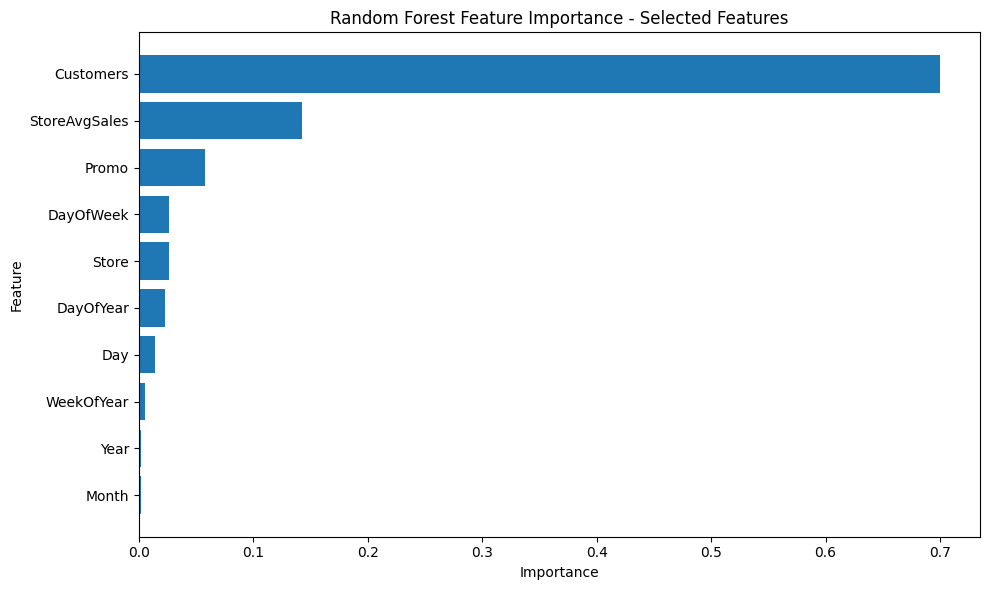


Important features used by the final model:
      Feature  Importance
    Customers    0.699889
StoreAvgSales    0.142517
        Promo    0.058061
    DayOfWeek    0.026638
        Store    0.026047
    DayOfYear    0.023111
          Day    0.013873
   WeekOfYear    0.005836
         Year    0.002109
        Month    0.001919


In [8]:
# ============================================================
# 8. FEATURE IMPORTANCE
# ============================================================

rf_model = trained_models["Random Forest"]

importance = (
    pd.DataFrame({
        "Feature": features,
        "Importance": rf_model.feature_importances_
    })
    .sort_values("Importance", ascending=False)
)

display(importance)

plt.figure(figsize=(10, 6))
plt.barh(importance["Feature"], importance["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance - Selected Features")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nImportant features used by the final model:")
print(importance.to_string(index=False))


## 9. Actual vs Predicted Sales

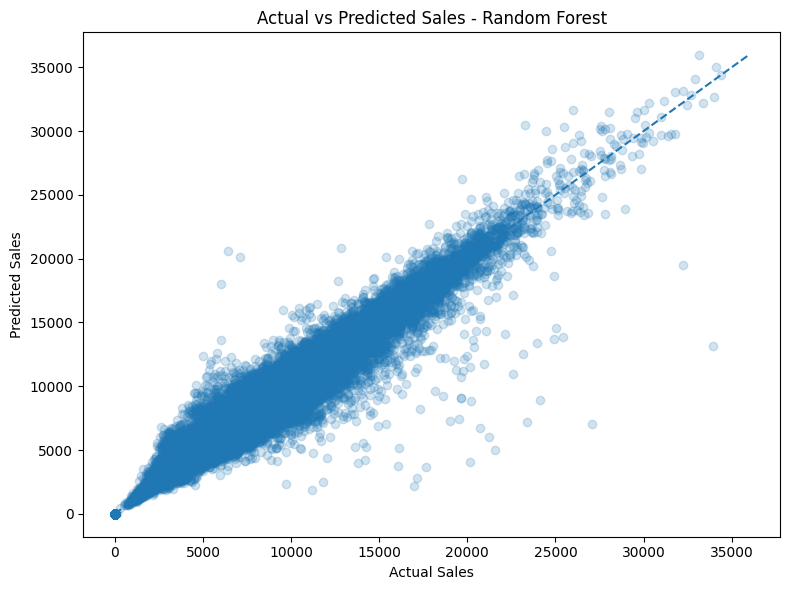

Closed-store predictions that are not zero: 0


In [9]:
# ==================================================================================================================
# 9. ACTUAL vs PREDICTED - Evaluation with the closed-store business rule.
# ==================================================================================================================

open_mask = eval_df["Open"].to_numpy() == 1
rf_pred = np.zeros(len(eval_df), dtype=float)
rf_pred[open_mask] = rf_model.predict(eval_df.loc[open_mask, features])
rf_pred[~open_mask] = 0

plt.figure(figsize=(8, 6))
plt.scatter(y_eval, rf_pred, alpha=0.2)

limit = max(y_eval.max(), rf_pred.max())
plt.plot([0, limit], [0, limit], linestyle="--")

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales - Random Forest")
plt.tight_layout()
plt.show()

print("Closed-store predictions that are not zero:",
      np.sum((eval_df["Open"].to_numpy() == 0) & (rf_pred != 0)))


## 10. Residual Analysis

Mean Error : -154.11047075693506
MAE        : 418.58260002323834
RMSE       : 670.4716866800145


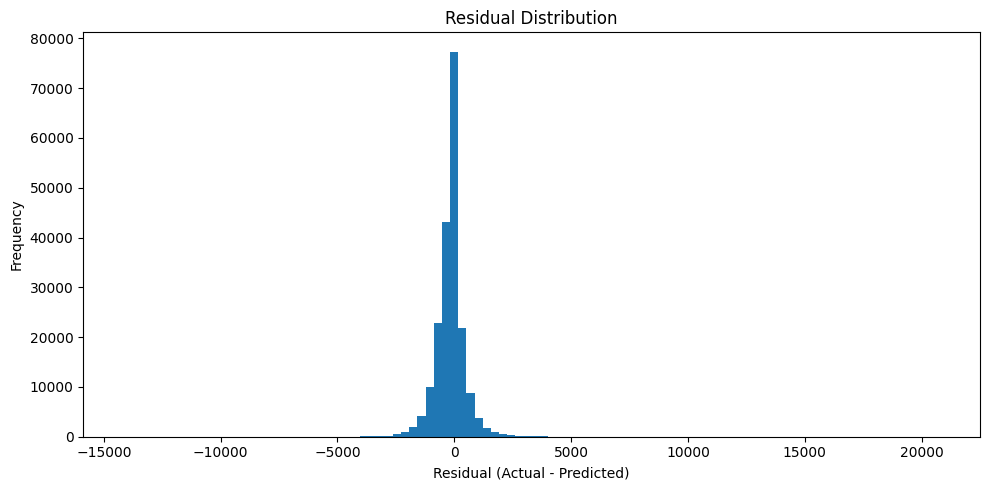

In [10]:
# ==================================================================================================================
# 10. RESIDUAL ANALYSIS - Check prediction errors.
# ==================================================================================================================

residuals = y_eval.to_numpy() - rf_pred

print("Mean Error :", residuals.mean())
print("MAE        :", mean_absolute_error(y_eval, rf_pred))
print("RMSE       :", np.sqrt(mean_squared_error(y_eval, rf_pred)))

plt.figure(figsize=(10, 5))
plt.hist(residuals, bins=100)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.tight_layout()
plt.show()


## 11. Live / Production Evaluation

In [11]:
# ============================================================
# 11. LIVE / PRODUCTION EVALUATION
# ============================================================

live_open_mask = live_df["Open"].to_numpy() == 1
live_pred = np.zeros(len(live_df), dtype=float)

live_pred[live_open_mask] = rf_model.predict(
    live_df.loc[live_open_mask, features]
)

# Hard business rule
live_pred[~live_open_mask] = 0

live_mae = mean_absolute_error(y_live, live_pred)
live_rmse = np.sqrt(mean_squared_error(y_live, live_pred))
live_r2 = r2_score(y_live, live_pred)

live_results = pd.DataFrame([{
    "Dataset": "Live / Production",
    "Records": len(y_live),
    "MAE": live_mae,
    "RMSE": live_rmse,
    "R2": live_r2,
    "Closed Predictions Non-Zero": int(
        np.sum((live_df["Open"].to_numpy() == 0) & (live_pred != 0))
    )
}])

display(live_results)

live_predictions = live_df[["Store", "Date", "Open", "Sales"]].copy()
live_predictions["PredictedSales"] = live_pred
live_predictions["Error"] = (
    live_predictions["Sales"] - live_predictions["PredictedSales"]
)

display(live_predictions.head(10))


,Dataset,Records,MAE,RMSE,R2,Closed Predictions Non-Zero
0,Live / Production,117209,401.222767,665.603288,0.967656,0


,Store,Date,Open,Sales,PredictedSales,Error
900000,981,2013-04-16,1,5021,5307.638821,-286.638821
900001,982,2013-04-16,1,5645,5778.096990,-133.096990
900002,983,2013-04-16,1,8593,8856.460093,-263.460093
900003,984,2013-04-16,1,4091,4215.156783,-124.156783
900004,985,2013-04-16,1,9580,5365.682351,4214.317649
900005,986,2013-04-16,1,6405,6661.072109,-256.072109
900006,987,2013-04-16,1,5430,5536.065009,-106.065009
900007,988,2013-04-16,1,3856,4058.079644,-202.079644
900008,989,2013-04-16,1,3852,4351.311071,-499.311071
900009,990,2013-04-16,1,3669,4038.326603,-369.326603


## 12. Final Model Summary

In [12]:
# ============================================================
# 12. FINAL MODEL SUMMARY
# ============================================================

print("=" * 70)
print("FINAL MODEL SUMMARY")
print("=" * 70)

print("Selected Model :", best_name)
print("Training Rows  :", len(train_df))
print("Open Rows Used :", len(open_train))
print("Evaluation Rows:", len(eval_df))
print("Live Rows      :", len(live_df))

print("\nBusiness Rule:")
print("Open = 0 -> Sales = 0")

print("\nSelected Features:")
for i, feature in enumerate(features, 1):
    print(f"{i:2}. {feature}")

print("\nEvaluation Performance:")
display(results_df[results_df["Model"] == best_name])

print("\nLive Performance:")
display(live_results)


FINAL MODEL SUMMARY
Selected Model : Random Forest
Training Rows  : 700000
Open Rows Used : 580096
Evaluation Rows: 200000
Live Rows      : 117209

Business Rule:
Open = 0 -> Sales = 0

Selected Features:
 1. Customers
 2. StoreAvgSales
 3. Promo
 4. Store
 5. DayOfWeek
 6. DayOfYear
 7. Day
 8. WeekOfYear
 9. Year
10. Month

Evaluation Performance:


,Model,MAE,RMSE,R2
0,Random Forest,418.5826,670.471687,0.966665



Live Performance:


,Dataset,Records,MAE,RMSE,R2,Closed Predictions Non-Zero
0,Live / Production,117209,401.222767,665.603288,0.967656,0


## 13. Export Model for Streamlit

This final cell saves the selected Random Forest model and all prediction-time information into **one `sales_model.pkl` file**.

The model is trained only on **open stores**. The deployment rule is:
- `Open = 0` → predicted Sales = `0`
- `Open = 1` → Random Forest prediction

The selected model features are based on the most important features from the previous feature-importance analysis.

In [13]:
# ============================================================
# 13. EXPORT ONE SELF-CONTAINED MODEL FILE FOR STREAMLIT
# ============================================================

import joblib
from pathlib import Path

MODEL_FILE = Path.cwd() / "sales_model.pkl"

# Save everything required by app.py in ONE PKL file.
#
# The package contains:
#   - trained Random Forest
#   - exact model features
#   - training-derived StoreAvgSales
#   - global average
#   - evaluation metrics
#   - split sizes
#   - business rule information
#   - feature importance

model_package = {
    "model": rf_model,
    "features": features,
    "store_avg": store_avg,
    "global_avg": float(global_avg),

    "metrics": {
        "MAE": float(results_df.loc[
            results_df["Model"] == "Random Forest", "MAE"
        ].iloc[0]),
        "RMSE": float(results_df.loc[
            results_df["Model"] == "Random Forest", "RMSE"
        ].iloc[0]),
        "R2": float(results_df.loc[
            results_df["Model"] == "Random Forest", "R2"
        ].iloc[0]),
    },

    "train_records": len(train_df),
    "open_train_records": len(open_train),
    "eval_records": len(eval_df),
    "live_records": len(live_df),

    # Deployment/business-rule settings
    "closed_store_sales": 0,
    "business_rule": "Open = 0 -> Sales = 0",

    "feature_importance": dict(zip(
        features,
        rf_model.feature_importances_
    ))
}

joblib.dump(model_package, MODEL_FILE, compress=3)

print("=" * 70)
print("MODEL EXPORT COMPLETE")
print("=" * 70)
print("File:", MODEL_FILE)
print("Size:", f"{MODEL_FILE.stat().st_size / (1024**2):,.1f} MB")
print("\nThe Streamlit app can now use ONLY this PKL file.")
print("\nIMPORTANT:")
print("Re-run this cell after every model/training change.")


MODEL EXPORT COMPLETE
File: d:\[18] AI-ML All\inttrvu AI\[01] Capstone Project\Predicting Sales for Differet Stores\sales_model.pkl
Size: 344.1 MB

The Streamlit app can now use ONLY this PKL file.

IMPORTANT:
Re-run this cell after every model/training change.
